# Part 2: Transformer Scaling Study

This notebook trains decoder only transformer language models at 5 different scales on SVG data, fits a power law scaling curve, and generates all required plots.

It loads the tokenizer and binary data files saved by Part 1. Make sure Part 1 has completed before running this.

Steps:
1. Load data and tokenizer from Part 1
2. Define GPT model (decoder only transformer)
3. Learning rate sweep on the Tiny model (7 LRs on log scale)
4. Train all 5 model sizes for 1 epoch with the best LR
5. Fit power law L = a * N^(alpha) + c
6. Plot scaling curve, training curves, LR sweep


In [1]:
!pip install tokenizers matplotlib numpy tqdm scipy -q

In [3]:
import os
import json
import math
import time
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer
from scipy.optimize import curve_fit

# UPDATE THIS to match your Part 1 project directory
PROJECT_DIR = Path("ml_final_project")

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
PLOT_DIR = PROJECT_DIR / "plots"

for d in [OUTPUT_DIR, PLOT_DIR]:
    d.mkdir(exist_ok=True, parents=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  Memory: 42.4 GB


## Step 1: Load Data and Tokenizer from Part 1

In [4]:
# Load tokenizer
tokenizer_path = DATA_DIR / "svg_tokenizer.json"
tokenizer = Tokenizer.from_file(str(tokenizer_path))
VOCAB_SIZE = tokenizer.get_vocab_size()
print(f"Loaded tokenizer from {tokenizer_path}")
print(f"  Vocab size: {VOCAB_SIZE}")

# Check binary files exist
for split in ["train", "val", "test"]:
    fpath = DATA_DIR / f"{split}.bin"
    data = np.memmap(str(fpath), dtype=np.uint16, mode='r')
    print(f"  {split}.bin: {len(data):,} tokens")

print("\nAll Part 1 files loaded successfully")

Loaded tokenizer from ml_final_project/data/svg_tokenizer.json
  Vocab size: 4096
  train.bin: 116,379,858 tokens
  val.bin: 1,181,388 tokens
  test.bin: 1,191,293 tokens

All Part 1 files loaded successfully


## Step 2: Model and Training Configuration

In [5]:
BLOCK_SIZE = 256
BATCH_SIZE = 64
DROPOUT = 0.1

MODEL_CONFIGS = {
    "Tiny":   {"d_model": 128,  "n_layers": 4,  "n_heads": 4,  "d_ff": 512},
    "Small":  {"d_model": 192,  "n_layers": 6,  "n_heads": 6,  "d_ff": 768},
    "Medium": {"d_model": 384,  "n_layers": 6,  "n_heads": 6,  "d_ff": 1536},
    "Large":  {"d_model": 512,  "n_layers": 10, "n_heads": 8,  "d_ff": 2048},
    "XL":     {"d_model": 768,  "n_layers": 12, "n_heads": 12, "d_ff": 3072},
}

print(f"Block size: {BLOCK_SIZE}")
print(f"Batch size: {BATCH_SIZE} sequences ({BATCH_SIZE * BLOCK_SIZE:,} tokens per step)")
print(f"Dropout: {DROPOUT}")
print(f"\nModel configurations:")
for name, cfg in MODEL_CONFIGS.items():
    print(f"  {name}: d_model={cfg['d_model']}, layers={cfg['n_layers']}, heads={cfg['n_heads']}, d_ff={cfg['d_ff']}")

Block size: 256
Batch size: 64 sequences (16,384 tokens per step)
Dropout: 0.1

Model configurations:
  Tiny: d_model=128, layers=4, heads=4, d_ff=512
  Small: d_model=192, layers=6, heads=6, d_ff=768
  Medium: d_model=384, layers=6, heads=6, d_ff=1536
  Large: d_model=512, layers=10, heads=8, d_ff=2048
  XL: d_model=768, layers=12, heads=12, d_ff=3072


## Step 3: GPT Model Definition

Decoder only transformer based on the nanoGPT architecture. Key components:
- Causal self attention with learned positional embeddings
- Pre norm (LayerNorm before attention and MLP)
- GELU activation in the feed forward network
- Weight tying between token embeddings and output head


In [6]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.register_buffer("bias", torch.tril(torch.ones(max_seq_len, max_seq_len))
                             .view(1, 1, max_seq_len, max_seq_len))

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_dim))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.c_fc = nn.Linear(d_model, d_ff)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_seq_len, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, max_seq_len, dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.tok_emb.weight = self.head.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.max_seq_len
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        tok_emb = self.tok_emb(idx)
        pos_emb = self.pos_emb(pos)
        x = self.drop(tok_emb + pos_emb)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


# Verify param counts
print("Parameter counts per model:")
for name, cfg in MODEL_CONFIGS.items():
    model = GPT(VOCAB_SIZE, cfg["d_model"], cfg["n_heads"], cfg["n_layers"],
                cfg["d_ff"], BLOCK_SIZE, DROPOUT)
    print(f"  {name}: {model.count_params():,}")
    del model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Parameter counts per model:
  Tiny: 1,350,400
  Small: 3,505,152
  Medium: 12,318,720
  Large: 33,753,088
  XL: 88,398,336


## Step 4: Data Loader

In [7]:
class SVGDataLoader:
    def __init__(self, split, block_size, batch_size, device):
        data_path = DATA_DIR / f"{split}.bin"
        self.data = np.memmap(str(data_path), dtype=np.uint16, mode='r')
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.n_tokens = len(self.data)
        self.n_batches = max(1, (self.n_tokens - block_size) // (batch_size * block_size))

    def get_batch(self):
        ix = torch.randint(len(self.data) - self.block_size - 1, (self.batch_size,))
        x = torch.stack([torch.from_numpy(self.data[i:i+self.block_size].astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy(self.data[i+1:i+1+self.block_size].astype(np.int64)) for i in ix])
        return x.to(self.device), y.to(self.device)

# Quick test
test_loader = SVGDataLoader("train", BLOCK_SIZE, BATCH_SIZE, DEVICE)
x, y = test_loader.get_batch()
print(f"Data loader working")
print(f"  Batch shape: {x.shape}")
print(f"  Train tokens: {test_loader.n_tokens:,}")
print(f"  Batches per epoch: {test_loader.n_batches:,}")
del test_loader, x, y

Data loader working
  Batch shape: torch.Size([64, 256])
  Train tokens: 116,379,858
  Batches per epoch: 7,103


## Step 5: Training Function

Uses cosine learning rate schedule with linear warmup (5 percent of total steps).
AdamW optimizer with gradient clipping at 1.0.


In [8]:
def get_lr(step, warmup_steps, max_steps, max_lr, min_lr):
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    if step >= max_steps:
        return min_lr
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))


@torch.no_grad()
def estimate_val_loss(model, val_loader, eval_iters=50):
    model.eval()
    losses = []
    for _ in range(eval_iters):
        x, y = val_loader.get_batch()
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return np.mean(losses)


def train_model(model_name, config, lr, num_epochs=1, log_interval=100, eval_interval=500, eval_iters=50):
    print(f"\nTraining {model_name} with LR {lr:.2e} on {DEVICE}")

    model = GPT(
        vocab_size=VOCAB_SIZE,
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        d_ff=config["d_ff"],
        max_seq_len=BLOCK_SIZE,
        dropout=DROPOUT,
    ).to(DEVICE)

    n_params = model.count_params()
    print(f"  Parameters: {n_params:,}")

    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()

    train_loader = SVGDataLoader("train", BLOCK_SIZE, BATCH_SIZE, DEVICE)
    val_loader = SVGDataLoader("val", BLOCK_SIZE, BATCH_SIZE, DEVICE)

    tokens_per_step = BATCH_SIZE * BLOCK_SIZE
    steps_per_epoch = train_loader.n_tokens // tokens_per_step
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = max(1, total_steps // 20)
    min_lr = lr * 0.1

    print(f"  Train tokens: {train_loader.n_tokens:,}")
    print(f"  Steps per epoch: {steps_per_epoch:,}")
    print(f"  Total steps: {total_steps:,}")
    print(f"  Warmup steps: {warmup_steps}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)

    train_losses = []
    val_losses = []
    total_tokens_processed = 0
    model.train()
    t_start = time.time()

    for step in range(total_steps):
        t_step = time.time()

        current_lr = get_lr(step, warmup_steps, total_steps, lr, min_lr)
        for pg in optimizer.param_groups:
            pg['lr'] = current_lr

        x, y = train_loader.get_batch()
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        total_tokens_processed += tokens_per_step
        step_dt = time.time() - t_step
        train_losses.append({"step": step, "loss": loss.item(), "lr": current_lr})

        if step % log_interval == 0:
            tok_per_sec = tokens_per_step / step_dt
            print(f"  Step {step:>6} of {total_steps} | loss {loss.item():.4f} | lr {current_lr:.2e} | {tok_per_sec:,.0f} tok/s")

        if step > 0 and step % eval_interval == 0:
            vl = estimate_val_loss(model, val_loader, eval_iters)
            val_losses.append({"step": step, "val_loss": vl})
            print(f"  Validation loss at step {step}: {vl:.4f}")

    final_val_loss = estimate_val_loss(model, val_loader, eval_iters)
    val_losses.append({"step": total_steps, "val_loss": final_val_loss})

    elapsed = time.time() - t_start
    avg_tok_per_sec = total_tokens_processed / elapsed

    gpu_mem_mb = 0
    if DEVICE == "cuda":
        gpu_mem_mb = torch.cuda.max_memory_allocated() / 1e6

    results = {
        "model_name": model_name,
        "n_params": n_params,
        "config": config,
        "lr": lr,
        "final_val_loss": final_val_loss,
        "final_train_loss": train_losses[-1]["loss"],
        "train_losses": train_losses,
        "val_losses": val_losses,
        "wall_time_sec": elapsed,
        "tokens_per_sec": avg_tok_per_sec,
        "gpu_mem_mb": gpu_mem_mb,
        "total_steps": total_steps,
        "total_tokens": total_tokens_processed,
    }

    print(f"  Finished {model_name} in {elapsed:.1f} seconds")
    print(f"  Final validation loss: {final_val_loss:.4f}")
    print(f"  Throughput: {avg_tok_per_sec:,.0f} tokens per second")
    print(f"  Peak GPU memory: {gpu_mem_mb:.0f} MB")

    del model, optimizer, train_loader, val_loader
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return results

print("Training function defined")

Training function defined


## Step 6: Learning Rate Sweep on Tiny Model

Testing 7 learning rates on a log scale. Each run trains the Tiny model for 1 epoch.
The LR with the lowest validation loss will be used for all larger models.


In [9]:
LR_CANDIDATES = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

lr_sweep_results = []

for lr_candidate in LR_CANDIDATES:
    print(f"\nTesting LR = {lr_candidate:.1e}")
    result = train_model(
        model_name=f"Tiny_lr{lr_candidate:.0e}",
        config=MODEL_CONFIGS["Tiny"],
        lr=lr_candidate,
        num_epochs=1,
        log_interval=200,
        eval_interval=500,
    )
    lr_sweep_results.append({
        "lr": lr_candidate,
        "val_loss": result["final_val_loss"],
        "train_loss": result["final_train_loss"],
    })

best_lr_entry = min(lr_sweep_results, key=lambda x: x["val_loss"])
BEST_LR = best_lr_entry["lr"]

print(f"\nLearning rate sweep results:")
for r in lr_sweep_results:
    marker = " (best)" if r["lr"] == BEST_LR else ""
    print(f"  LR {r['lr']:.1e}: val loss = {r['val_loss']:.4f}, train loss = {r['train_loss']:.4f}{marker}")

print(f"\nBest learning rate: {BEST_LR:.1e}")

with open(OUTPUT_DIR / "lr_sweep_results.json", "w") as f:
    json.dump(lr_sweep_results, f, indent=2)
print("LR sweep results saved")


Testing LR = 1.0e-05

Training Tiny_lr1e-05 with LR 1.00e-05 on cuda
  Parameters: 1,350,400
  Train tokens: 116,379,858
  Steps per epoch: 7,103
  Total steps: 7,103
  Warmup steps: 355
  Step      0 of 7103 | loss 8.3492 | lr 2.82e-08 | 7,119 tok/s
  Step    200 of 7103 | loss 7.7541 | lr 5.66e-06 | 776,535 tok/s
  Step    400 of 7103 | loss 7.2572 | lr 1.00e-05 | 972,345 tok/s
  Validation loss at step 500: 6.9805
  Step    600 of 7103 | loss 6.8138 | lr 9.97e-06 | 931,524 tok/s
  Step    800 of 7103 | loss 6.4131 | lr 9.90e-06 | 994,954 tok/s
  Step   1000 of 7103 | loss 6.0600 | lr 9.80e-06 | 981,468 tok/s
  Validation loss at step 1000: 6.0164
  Step   1200 of 7103 | loss 5.7513 | lr 9.66e-06 | 980,894 tok/s
  Step   1400 of 7103 | loss 5.4219 | lr 9.48e-06 | 976,309 tok/s
  Validation loss at step 1500: 5.2450
  Step   1600 of 7103 | loss 5.1834 | lr 9.27e-06 | 986,938 tok/s
  Step   1800 of 7103 | loss 4.8793 | lr 9.02e-06 | 1,003,131 tok/s
  Step   2000 of 7103 | loss 4.7162 

## Step 7: LR Sweep Plot

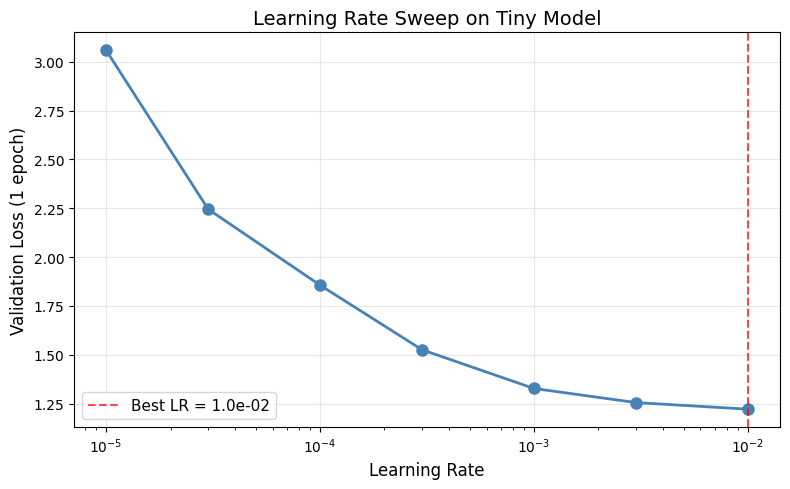

LR sweep plot saved


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
lrs = [r["lr"] for r in lr_sweep_results]
vl = [r["val_loss"] for r in lr_sweep_results]

ax.semilogx(lrs, vl, 'o-', color='steelblue', markersize=8, linewidth=2)
ax.axvline(BEST_LR, color='red', linestyle='--', alpha=0.7, label=f'Best LR = {BEST_LR:.1e}')
ax.set_xlabel("Learning Rate", fontsize=12)
ax.set_ylabel("Validation Loss (1 epoch)", fontsize=12)
ax.set_title("Learning Rate Sweep on Tiny Model", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "lr_sweep.png"), dpi=150)
plt.show()
print("LR sweep plot saved")

## Step 8: Train All 5 Model Sizes

Training each model for 1 epoch using the best LR from the sweep.

If you are short on compute, you can comment out the XL model and note this in the report.


In [11]:
all_results = {}

for model_name, config in MODEL_CONFIGS.items():
    result = train_model(
        model_name=model_name,
        config=config,
        lr=BEST_LR,
        num_epochs=1,
        log_interval=100,
        eval_interval=500,
    )
    all_results[model_name] = result

# Save detailed results
with open(OUTPUT_DIR / "scaling_results.json", "w") as f:
    json.dump(all_results, f, indent=2, default=str)

print("\nAll models trained. Summary:")
print(f"{'Model':<10} {'Params':>12} {'Val Loss':>10} {'Train Loss':>12} {'Time':>10} {'Tok/s':>12} {'GPU MB':>8}")
for name in MODEL_CONFIGS:
    r = all_results[name]
    print(f"{name:<10} {r['n_params']:>12,} {r['final_val_loss']:>10.4f} {r['final_train_loss']:>12.4f} "
          f"{r['wall_time_sec']:>9.0f}s {r['tokens_per_sec']:>12,.0f} {r['gpu_mem_mb']:>8.0f}")


Training Tiny with LR 1.00e-02 on cuda
  Parameters: 1,350,400
  Train tokens: 116,379,858
  Steps per epoch: 7,103
  Total steps: 7,103
  Warmup steps: 355
  Step      0 of 7103 | loss 8.3352 | lr 2.82e-05 | 668,640 tok/s
  Step    100 of 7103 | loss 2.8703 | lr 2.85e-03 | 939,330 tok/s
  Step    200 of 7103 | loss 2.4076 | lr 5.66e-03 | 1,001,479 tok/s
  Step    300 of 7103 | loss 2.0254 | lr 8.48e-03 | 1,001,406 tok/s
  Step    400 of 7103 | loss 1.9143 | lr 1.00e-02 | 1,051,335 tok/s
  Step    500 of 7103 | loss 1.8928 | lr 9.99e-03 | 1,008,978 tok/s
  Validation loss at step 500: 1.7758
  Step    600 of 7103 | loss 1.7173 | lr 9.97e-03 | 953,881 tok/s
  Step    700 of 7103 | loss 1.6446 | lr 9.94e-03 | 1,021,653 tok/s
  Step    800 of 7103 | loss 1.5232 | lr 9.90e-03 | 991,451 tok/s
  Step    900 of 7103 | loss 1.5681 | lr 9.86e-03 | 1,070,247 tok/s
  Step   1000 of 7103 | loss 1.6742 | lr 9.80e-03 | 975,173 tok/s
  Validation loss at step 1000: 1.5818
  Step   1100 of 7103 | los

## Step 9: Scaling Plot with Power Law Fit

Fitting the power law L = a * N^(negative alpha) + c where N is the number of parameters and L is the validation loss after 1 epoch.


Power law fit results:
  L = 1000000.0000 * N^(-1.1619) + 1.1104
  alpha = 1.1619 (uncertainty 12.3686)
  R squared = 0.0412


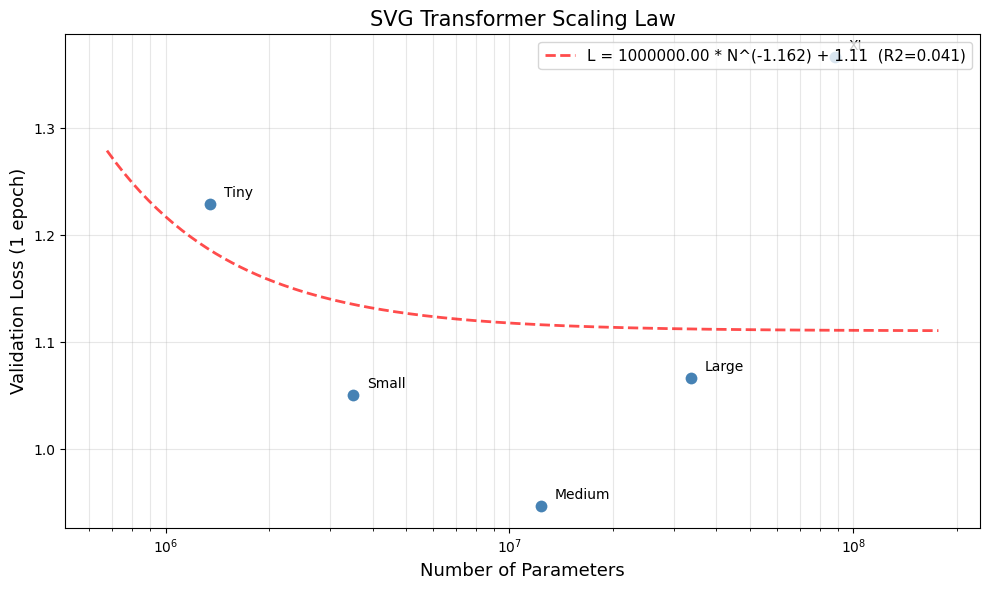

Scaling plot saved


In [12]:
model_names = list(all_results.keys())
param_counts = np.array([all_results[n]["n_params"] for n in model_names])
val_losses_final = np.array([all_results[n]["final_val_loss"] for n in model_names])

def power_law(N, a, alpha, c):
    return a * np.power(N, -alpha) + c

try:
    popt, pcov = curve_fit(
        power_law, param_counts, val_losses_final,
        p0=[10.0, 0.1, 1.0],
        bounds=([0, 0, 0], [1e6, 2.0, 10.0]),
        maxfev=10000,
    )
    a_fit, alpha_fit, c_fit = popt
    perr = np.sqrt(np.diag(pcov))

    predicted = power_law(param_counts, *popt)
    ss_res = np.sum((val_losses_final - predicted) ** 2)
    ss_tot = np.sum((val_losses_final - np.mean(val_losses_final)) ** 2)
    r_squared = 1 - ss_res / ss_tot

    print("Power law fit results:")
    print(f"  L = {a_fit:.4f} * N^({-alpha_fit:.4f}) + {c_fit:.4f}")
    print(f"  alpha = {alpha_fit:.4f} (uncertainty {perr[1]:.4f})")
    print(f"  R squared = {r_squared:.4f}")
    fit_success = True
except Exception as e:
    print(f"Power law fit failed: {e}")
    fit_success = False

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(param_counts, val_losses_final, s=100, c='steelblue', zorder=5, edgecolors='white', linewidth=1.5)

for i, name in enumerate(model_names):
    ax.annotate(name, (param_counts[i], val_losses_final[i]),
                textcoords="offset points", xytext=(10, 5), fontsize=10)

if fit_success:
    x_smooth = np.logspace(np.log10(param_counts.min() * 0.5),
                            np.log10(param_counts.max() * 2), 200)
    y_smooth = power_law(x_smooth, *popt)
    label_text = f'L = {a_fit:.2f} * N^({-alpha_fit:.3f}) + {c_fit:.2f}  (R2={r_squared:.3f})'
    ax.plot(x_smooth, y_smooth, 'r--', linewidth=2, alpha=0.7, label=label_text)
    ax.legend(fontsize=11, loc='upper right')

ax.set_xscale('log')
ax.set_xlabel("Number of Parameters", fontsize=13)
ax.set_ylabel("Validation Loss (1 epoch)", fontsize=13)
ax.set_title("SVG Transformer Scaling Law", fontsize=15)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "scaling_plot.png"), dpi=150)
plt.show()
print("Scaling plot saved")

## Step 10: Training Loss Curves

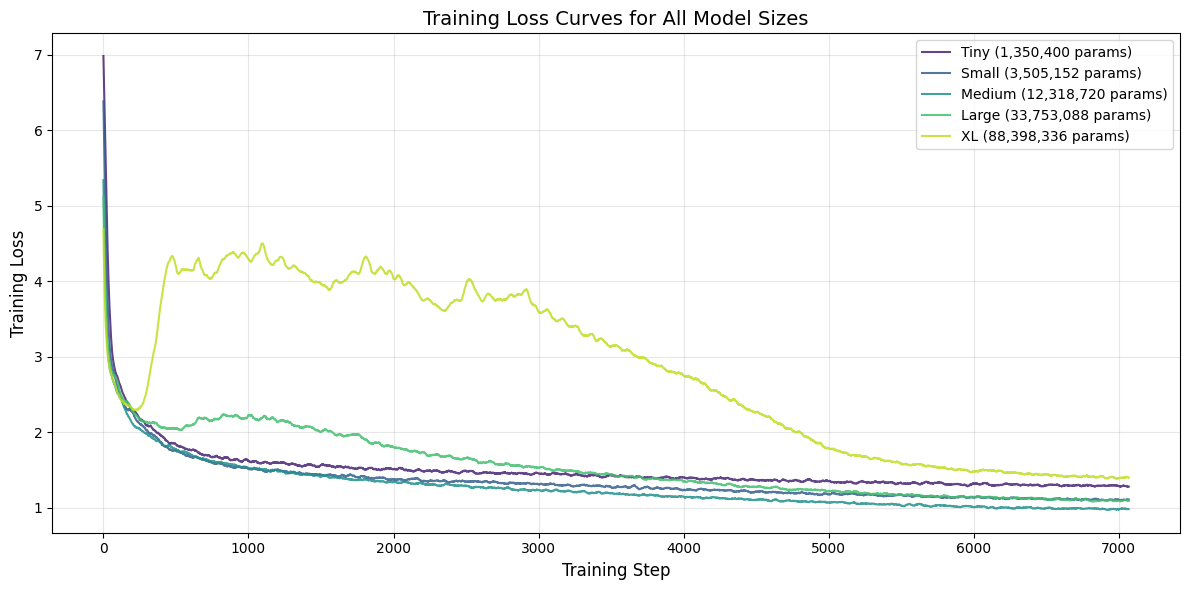

Training curves plot saved


In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(MODEL_CONFIGS)))

for i, (name, result) in enumerate(all_results.items()):
    steps = [t["step"] for t in result["train_losses"]]
    losses = [t["loss"] for t in result["train_losses"]]
    window = max(1, len(losses) // 200)
    if window > 1:
        smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
        smooth_steps = steps[:len(smoothed)]
    else:
        smoothed = losses
        smooth_steps = steps
    ax.plot(smooth_steps, smoothed, color=colors[i], linewidth=1.5, alpha=0.85,
            label=f"{name} ({result['n_params']:,} params)")

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("Training Loss Curves for All Model Sizes", fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "training_curves.png"), dpi=150)
plt.show()
print("Training curves plot saved")

## Step 11: Save Summary

In [14]:
summary = {
    "best_lr": BEST_LR,
    "lr_sweep": lr_sweep_results,
    "scaling_exponent_alpha": float(alpha_fit) if fit_success else None,
    "r_squared": float(r_squared) if fit_success else None,
    "power_law_params": {
        "a": float(a_fit),
        "alpha": float(alpha_fit),
        "c": float(c_fit)
    } if fit_success else None,
    "models": {},
}

for name in MODEL_CONFIGS:
    r = all_results[name]
    summary["models"][name] = {
        "n_params": r["n_params"],
        "config": r["config"],
        "final_val_loss": r["final_val_loss"],
        "final_train_loss": r["final_train_loss"],
        "wall_time_sec": r["wall_time_sec"],
        "tokens_per_sec": r["tokens_per_sec"],
        "gpu_mem_mb": r["gpu_mem_mb"],
        "total_steps": r["total_steps"],
    }

with open(OUTPUT_DIR / "part2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Part 2 complete. Summary saved to outputs/part2_summary.json")
print("")
print(f"Best learning rate: {BEST_LR:.1e}")
if fit_success:
    print(f"Scaling exponent alpha: {alpha_fit:.4f}")
    print(f"R squared: {r_squared:.4f}")
print("")
print("Plots saved:")
print(f"  {PLOT_DIR / 'lr_sweep.png'}")
print(f"  {PLOT_DIR / 'scaling_plot.png'}")
print(f"  {PLOT_DIR / 'training_curves.png'}")

Part 2 complete. Summary saved to outputs/part2_summary.json

Best learning rate: 1.0e-02
Scaling exponent alpha: 1.1619
R squared: 0.0412

Plots saved:
  ml_final_project/plots/lr_sweep.png
  ml_final_project/plots/scaling_plot.png
  ml_final_project/plots/training_curves.png
